# Migration Discourse Analysis

## Computational Analysis of Migration-Related Discourse in European Parliament Speeches

This project examines migration-related discourse in European Parliament speeches using computational linguistics and natural language processing techniques.

The analysis focuses on the frequency and use of migration-related vocabulary, changes in discourse over time, semantic patterns, and sentiment. A particular focus is placed on comparing discourse before and after 2015.

In [ ]:
#!pip install pyreadr

In [3]:
import pyreadr

In [5]:
result = pyreadr.read_r("../data/EUPDCorp_1999-2024_v1.rds")

df = result[None]
df.head()

,doc_id,file,term_no,date,datemonth,year,agenda,firstname,lastname,country,...,party_db_code,epg_short,epg_long,epg_partyfacts_id,party_name,partyfacts_id,ches_id,gps_id,speech,speech_en
0,1.0,CRE-5-1999-07-20-FNL,5,1999-07-20,199907.0,1999.0,Genoptagelse af sessionen,Giorgio,Napolitano,ITA,...,NI,IND,Independent,6402.0,Democratici di Sinistra,934,NaN,594.0,Dichiaro ripresa la sessione interrotta il 7 m...,I declare resumed the session adjourned on 7 M...
1,2.0,CRE-5-1999-07-20-FNL,5,1999-07-20,199907.0,1999.0,Genoptagelse af sessionen,Brian,Crowley,IRL,...,UEN,NAT,Union for Europe of the Nations,8760.0,Fianna Fáil Party,1055,701.0,435.0,"Mr President, I should like to thank you for g...","Mr President, I should like to thank you for g..."
2,3.0,CRE-5-1999-07-20-FNL,5,1999-07-20,199907.0,1999.0,Genoptagelse af sessionen,Giorgio,Napolitano,ITA,...,NI,IND,Independent,6402.0,Democratici di Sinistra,934,NaN,594.0,"Onorevole Crowley, la sua protesta sarà senz'a...","Mr. Crowley, your protest will certainly be no..."
3,4.0,CRE-5-1999-07-20-FNL,5,1999-07-20,199907.0,1999.0,Aldersformanden,Giorgio,Napolitano,ITA,...,NI,IND,Independent,6402.0,Democratici di Sinistra,934,NaN,594.0,"Comunico che, ai sensi dell'articolo 12, parag...","I have to inform you that, pursuant to Rule 12..."
4,5.0,CRE-5-1999-07-20-FNL,5,1999-07-20,199907.0,1999.0,Aldersformanden,Marco,Cappato,ITA,...,NI,IND,Independent,6402.0,Lista Emma Bonino,2134,NaN,594.0,"Signor Presidente, chiedo la parola per un ric...","Mr President, I would like to ask for the floo..."


In [6]:
df.columns

Index(['doc_id', 'file', 'term_no', 'date', 'datemonth', 'year', 'agenda',
       'firstname', 'lastname', 'country', 'language', 'nationality', 'gender',
       'birth_year', 'birth_place', 'mepid', 'moderator', 'party_db_code',
       'epg_short', 'epg_long', 'epg_partyfacts_id', 'party_name',
       'partyfacts_id', 'ches_id', 'gps_id', 'speech', 'speech_en'],
      dtype='str')

In [7]:
print(df['speech_en'].iloc[0])

I declare resumed the session adjourned on 7 May 1999 and open the sitting provided for in Article 10 (3) of the Act electing the representatives of the European Parliament by direct universal suffrage and in Article 10 (3) of Parliament's Rules of Procedure. Mr Crowley has asked for the floor on a point of order.


## Refugee-Related Vocabulary

In [ ]:
# Count occurrences of refugee-related terms in the corpus
df['speech_en'].fillna('').str.lower().str.count(r'\b\w*refugee[\w-]*').sum()

np.int64(27944)

In [ ]:
# Identify the most frequent refugee-related terms
import re
from collections import Counter

text_ref = " ".join(df['speech_en'].dropna().str.lower())
matches_ref_word = re.findall(r'\b\w*refugee[\w-]*', text_ref)

Counter(matches_ref_word).most_common(20)

[('refugees', 19587),
 ('refugee', 8337),
 ('refugee-hosting', 6),
 ('refugee-friendly', 3),
 ('refugee-related', 3),
 ('refugee-migrant', 2),
 ('refugee-migration', 2),
 ('ofrefugee', 1),
 ('refugeesʼ', 1),
 ('refugee-acceptance', 1),
 ('refugee-producing', 1)]

In [ ]:
# Identify the most frequent refugee-related phrases

matches_ref_ph= re.findall(r'\b\w+\s+refugee\w*\s+\w+\b', text_ref)

Counter(matches_ref_ph).most_common(30)

[('the refugee crisis', 1959),
 ('of refugees and', 989),
 ('of refugees in', 354),
 ('and refugee crisis', 338),
 ('of refugees from', 285),
 ('european refugee fund', 239),
 ('the refugee problem', 222),
 ('for refugees and', 209),
 ('in refugee camps', 196),
 ('the refugee camps', 195),
 ('of refugees to', 175),
 ('current refugee crisis', 162),
 ('of refugees is', 156),
 ('of refugees into', 155),
 ('the refugee and', 147),
 ('of refugees are', 143),
 ('for refugees in', 118),
 ('the refugees and', 116),
 ('the refugees in', 109),
 ('and refugees in', 106),
 ('of refugees who', 105),
 ('the refugee issue', 102),
 ('the refugees who', 101),
 ('and refugee flows', 96),
 ('syrian refugees in', 94),
 ('to refugees and', 91),
 ('the refugees are', 83),
 ('women refugees and', 81),
 ('000 refugees in', 70),
 ('a refugee crisis', 69)]

In [ ]:
# Identify speeches containing refugee-related terms
filtered_df_ref = df[df['speech_en'].str.contains('refugee', case=False, na=False)]
filtered_df_ref['speech_en'].head(5)

71     Mr President, Mr President of the Council, Mr ...
110    I would like to thank Mr Halos, the Finnish Fo...
112    Mr. Speaker, Madam Secretary, I have to go. As...
119    Member of the Commission . – (DE) Honoured Pre...
127    Mr President, the Finnish Presidency has a dif...
Name: speech_en, dtype: str

In [12]:
len(filtered_df_ref)

16156

## Migration-Related Vocabulary

In [ ]:
# Count occurrences of "migra" in the corpus
df['speech_en'].fillna('').str.lower().str.count(r'\b\w*migra[\w-]*').sum()

np.int64(61012)

In [ ]:
# Identify the most frequent "migra" terms
import re
from collections import Counter

text_migra = " ".join(df['speech_en'].dropna().str.lower())
matches_migra_word = re.findall(r'\b\w*migra[\w-]*', text_migra)

Counter(matches_migra_word).most_common(20)

[('migration', 23257),
 ('immigration', 14292),
 ('migrants', 11264),
 ('immigrants', 5564),
 ('migrant', 2549),
 ('migratory', 1421),
 ('immigrant', 798),
 ('emigration', 587),
 ('migrate', 278),
 ('emigrate', 248),
 ('migrating', 94),
 ('emigrants', 87),
 ('migrations', 80),
 ('emigrated', 79),
 ('migration-related', 64),
 ('immigrate', 48),
 ('migrated', 48),
 ('emigrating', 46),
 ('immigrationist', 32),
 ('emigrant', 16)]

In [ ]:
# Identify the most frequent "migra" phrases
matches_migra_ph = re.findall(r'\b\w+\s+migra\w*\s+\w+\b', text_migra)

Counter(matches_migra_ph).most_common(30)

[('the migration crisis', 1424),
 ('of migrants and', 635),
 ('of migration flows', 607),
 ('on migration and', 523),
 ('of migration and', 477),
 ('the migration and', 333),
 ('the migrant crisis', 316),
 ('of migrants in', 248),
 ('of migrant workers', 192),
 ('and migration policy', 190),
 ('current migration crisis', 178),
 ('european migration policy', 158),
 ('the migration issue', 149),
 ('of migrants to', 145),
 ('the migration of', 140),
 ('s migration policy', 133),
 ('of migration is', 124),
 ('to migration and', 124),
 ('of migration in', 121),
 ('and migration crisis', 116),
 ('managing migration flows', 115),
 ('of migration policy', 114),
 ('the migration problem', 110),
 ('manage migration flows', 105),
 ('illegal migration and', 102),
 ('the migration flows', 101),
 ('of migrants from', 100),
 ('of migrants who', 100),
 ('the migratory pressure', 99),
 ('the migratory flows', 97)]

In [ ]:
# Identify speeches containing migration-related terms
filtered_df_mig = df[df['speech_en'].str.contains('migra', case=False, na=False)]
filtered_df_mig['speech_en'].head(5)

109    the Council.  Mr President, ladies and gentlem...
121    Mr President, I should like to begin by emphas...
245    Madam President, with regard to the joint reso...
402    - Mr President, the LO and LCR members will vo...
465    Mr Prodi, on behalf of the Italian Socialists,...
Name: speech_en, dtype: str

In [17]:
len(filtered_df_mig)

30614

## Asylum-Related Vocabulary

In [ ]:
# Count occurrences of asylum-related terms in the corpus
df['speech_en'].fillna('').str.lower().str.count(r'\b\w*asylum[\w-]*').sum()

np.int64(17523)

In [ ]:
# Identify the most frequent asylum-related terms
import re
from collections import Counter

text_asy = " ".join(df['speech_en'].dropna().str.lower())
matches_asy_word = re.findall(r'\b\w*asylum[\w-]*', text_asy)

Counter(matches_asy_word).most_common(20)

[('asylum', 17385),
 ('asylum-seekers', 83),
 ('asylum-seeking', 16),
 ('asylum-seeker', 12),
 ('asylum-related', 10),
 ('asylums', 8),
 ('asylumseekers', 3),
 ('asylumseeker', 2),
 ('asylum-shopping', 2),
 ('asylum-producing', 1),
 ('asylum-friendly', 1)]

In [ ]:
# Identify the most frequent asylum-related phrases
matches_asy_ph = re.findall(r'\b\w+\s+asylum\w*\s+\w+\b', text_asy)

Counter(matches_asy_ph).most_common(30)

[('of asylum seekers', 1087),
 ('european asylum system', 846),
 ('and asylum seekers', 697),
 ('european asylum support', 667),
 ('on asylum and', 322),
 ('of asylum and', 316),
 ('and asylum policy', 308),
 ('for asylum seekers', 287),
 ('of asylum applications', 228),
 ('the asylum system', 212),
 ('common asylum policy', 211),
 ('common asylum system', 203),
 ('european asylum policy', 168),
 ('the asylum and', 153),
 ('the asylum package', 151),
 ('to asylum and', 137),
 ('and asylum policies', 127),
 ('an asylum application', 116),
 ('for asylum in', 116),
 ('the asylum procedure', 116),
 ('000 asylum seekers', 112),
 ('that asylum seekers', 110),
 ('european asylum and', 105),
 ('common asylum and', 91),
 ('to asylum seekers', 89),
 ('seeking asylum in', 89),
 ('an asylum seeker', 77),
 ('of asylum is', 74),
 ('for asylum and', 73),
 ('of asylum policy', 67)]

In [ ]:
# Identify speeches containing asylum-related terms
filtered_df_asy = df[df['speech_en'].str.contains('asylum', case=False, na=False)]
filtered_df_asy['speech_en'].head(5)

109    the Council.  Mr President, ladies and gentlem...
110    I would like to thank Mr Halos, the Finnish Fo...
121    Mr President, I should like to begin by emphas...
125    Mr President, listening to the Finnish preside...
129    (FR) Madam President-in-Office of the Council,...
Name: speech_en, dtype: str

In [22]:
len(filtered_df_asy)

9427

## Temporal Analysis

In [23]:
migra_by_year = df[df['speech_en'].str.contains('migra', case=False, na=False)]

migra_year_counts = migra_by_year.groupby('year').size()

migra_year_counts

year
1999.0     124
2000.0     419
2001.0     428
2002.0     475
2003.0     490
2004.0     397
2005.0     455
2006.0     732
2007.0     712
2008.0     805
2009.0     630
2010.0     683
2011.0    1186
2012.0     652
2013.0    1142
2014.0    1556
2015.0    4808
2016.0    7390
2017.0    1600
2018.0    1675
2019.0     966
2020.0     665
2021.0    1063
2022.0     822
2023.0     638
2024.0     101
dtype: int64

In [24]:
ref_by_year = df[df['speech_en'].str.contains('refugee', case=False, na=False)]

ref_year_counts = ref_by_year.groupby('year').size()

ref_year_counts

year
1999.0     137
2000.0     274
2001.0     297
2002.0     212
2003.0     177
2004.0     141
2005.0     157
2006.0     179
2007.0     175
2008.0     188
2009.0     203
2010.0     241
2011.0     541
2012.0     299
2013.0     574
2014.0     474
2015.0    3371
2016.0    4743
2017.0     843
2018.0     748
2019.0     411
2020.0     280
2021.0     402
2022.0     881
2023.0     187
2024.0      21
dtype: int64

In [25]:
asy_by_year = df[df['speech_en'].str.contains('asylum', case=False, na=False)]

asy_year_counts = asy_by_year.groupby('year').size()

asy_year_counts

year
1999.0     103
2000.0     208
2001.0     248
2002.0     255
2003.0     162
2004.0     204
2005.0     131
2006.0     118
2007.0     104
2008.0     155
2009.0     240
2010.0     189
2011.0     408
2012.0     210
2013.0     511
2014.0     471
2015.0    1602
2016.0    1938
2017.0     359
2018.0     397
2019.0     314
2020.0     188
2021.0     381
2022.0     263
2023.0     247
2024.0      21
dtype: int64

In [ ]:
#!pip install matplotlib

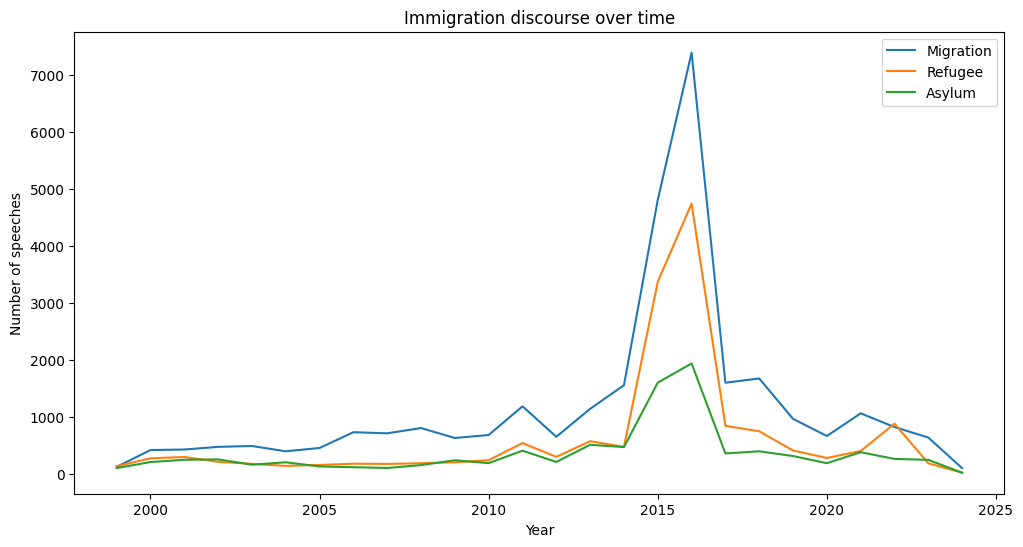

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))

migra_year_counts.plot(label='Migration')
ref_year_counts.plot(label='Refugee')
asy_year_counts.plot(label='Asylum')

plt.legend()

plt.xlabel("Year")
plt.ylabel("Number of speeches")
plt.title("Immigration discourse over time")

plt.show()

# Splitting corpus into two periods

### Before the spike 1999-2014
### During and after spike 2015-2024

In [28]:
before_2015 = df[df['year'] < 2015]

after_2015 = df[df['year'] >= 2015]

### Migration-Related Discourse

In [29]:
before_migra = before_2015[
    before_2015['speech_en'].str.contains('migra', case=False, na=False)
]

after_migra = after_2015[
    after_2015['speech_en'].str.contains('migra', case=False, na=False)
]

In [ ]:
# Identify the most frequent "migra" phrases before 2015
text_before_migra = " ".join(before_migra['speech_en'].dropna().str.lower())

matches_before_migra = re.findall(r'\b\w+\s+migra\w*\s+\w+\b', text_before_migra)

Counter(matches_before_migra).most_common(20)

[('of migration flows', 352),
 ('of migrants and', 167),
 ('of migrant workers', 144),
 ('of migration and', 97),
 ('on migration and', 88),
 ('the migration of', 76),
 ('of migrants in', 76),
 ('manage migration flows', 63),
 ('and migration policy', 59),
 ('managing migration flows', 59),
 ('european migration policy', 55),
 ('and migration fund', 49),
 ('illegal migration and', 42),
 ('on migration flows', 39),
 ('of migratory flows', 37),
 ('to migration and', 36),
 ('legal migration and', 36),
 ('of migration is', 35),
 ('of migration policy', 35),
 ('of migrant women', 35)]

In [ ]:
# Identify the most frequent "migra" phrases from 2015 onward
text_after_migra = " ".join(after_migra['speech_en'].dropna().str.lower())

matches_after_migra = re.findall(r'\b\w+\s+migra\w*\s+\w+\b', text_after_migra)

Counter(matches_after_migra).most_common(20)

[('the migration crisis', 1420),
 ('of migrants and', 468),
 ('on migration and', 435),
 ('of migration and', 380),
 ('the migrant crisis', 316),
 ('the migration and', 315),
 ('of migration flows', 255),
 ('current migration crisis', 178),
 ('of migrants in', 171),
 ('the migration issue', 139),
 ('and migration policy', 131),
 ('of migrants to', 119),
 ('and migration crisis', 116),
 ('european migration policy', 103),
 ('s migration policy', 100),
 ('the migration problem', 95),
 ('of migration in', 90),
 ('of migration is', 89),
 ('to migration and', 88),
 ('the migration pact', 80)]

### Refugee-Related Discourse

In [32]:
before_ref = before_2015[
    before_2015['speech_en'].str.contains('refugee', case=False, na=False)
]

after_ref = after_2015[
    after_2015['speech_en'].str.contains('ref', case=False, na=False)
]

In [ ]:
# Identify the most frequent refugee-related phrases before 2015
text_before_ref = " ".join(before_ref['speech_en'].dropna().str.lower())

matches_before_ref = re.findall(r'\b\w+\s+refugee\w*\s+\w+\b', text_before_ref)

Counter(matches_before_ref).most_common(20)

[('of refugees and', 291),
 ('european refugee fund', 239),
 ('of refugees in', 96),
 ('the refugee camps', 96),
 ('of refugees from', 94),
 ('in refugee camps', 77),
 ('for refugees and', 60),
 ('the refugee problem', 56),
 ('of refugees to', 51),
 ('the refugees in', 46),
 ('of refugees is', 45),
 ('of refugees who', 44),
 ('of refugees are', 41),
 ('syrian refugees in', 40),
 ('the refugees and', 38),
 ('of refugee status', 37),
 ('to refugees and', 35),
 ('the refugees who', 34),
 ('the refugee fund', 33),
 ('and refugees in', 32)]

In [ ]:
# Identify the most frequent refugee-related phrases from 2015 onward
text_after_ref = " ".join(after_ref['speech_en'].dropna().str.lower())

matches_after_ref = re.findall(r'\b\w+\s+refugee\w*\s+\w+\b', text_after_ref)

Counter(matches_after_ref).most_common(20)

[('the refugee crisis', 1940),
 ('of refugees and', 698),
 ('and refugee crisis', 337),
 ('of refugees in', 258),
 ('of refugees from', 191),
 ('the refugee problem', 166),
 ('current refugee crisis', 160),
 ('for refugees and', 149),
 ('the refugee and', 139),
 ('of refugees into', 126),
 ('of refugees to', 124),
 ('in refugee camps', 119),
 ('of refugees is', 111),
 ('of refugees are', 102),
 ('the refugee camps', 99),
 ('for refugees in', 95),
 ('the refugee issue', 90),
 ('women refugees and', 81),
 ('the refugees and', 78),
 ('and refugees in', 74)]

### Asylum-Related Discourse

In [35]:
before_asy = before_2015[
    before_2015['speech_en'].str.contains('asylum', case=False, na=False)
]

after_asy = after_2015[
    after_2015['speech_en'].str.contains('asylum', case=False, na=False)
]

In [ ]:
# Identify the most frequent asylum-related phrases before 2015
text_before_asy = " ".join(before_asy['speech_en'].dropna().str.lower())

matches_before_asy = re.findall(r'\b\w+\s+asylum\w*\s+\w+\b', text_before_asy)

Counter(matches_before_asy).most_common(20)

[('of asylum seekers', 554),
 ('european asylum system', 415),
 ('and asylum seekers', 202),
 ('of asylum and', 188),
 ('on asylum and', 186),
 ('european asylum support', 164),
 ('and asylum policy', 152),
 ('for asylum seekers', 143),
 ('common asylum system', 123),
 ('common asylum policy', 114),
 ('the asylum package', 110),
 ('of asylum applications', 109),
 ('an asylum application', 96),
 ('the asylum system', 96),
 ('european asylum policy', 88),
 ('that asylum seekers', 75),
 ('to asylum and', 70),
 ('the asylum procedure', 69),
 ('the asylum and', 56),
 ('of asylum is', 54)]

In [ ]:
# Identify the most frequent asylum-related phrases from 2015 onward
text_after_asy = " ".join(after_asy['speech_en'].dropna().str.lower())

matches_after_asy = re.findall(r'\b\w+\s+asylum\w*\s+\w+\b', text_after_asy)

Counter(matches_after_asy).most_common(20)

[('of asylum seekers', 533),
 ('european asylum support', 503),
 ('and asylum seekers', 495),
 ('european asylum system', 431),
 ('and asylum policy', 156),
 ('for asylum seekers', 144),
 ('on asylum and', 136),
 ('of asylum and', 128),
 ('of asylum applications', 119),
 ('the asylum system', 116),
 ('000 asylum seekers', 101),
 ('common asylum policy', 97),
 ('the asylum and', 97),
 ('european asylum policy', 80),
 ('common asylum system', 80),
 ('and asylum policies', 78),
 ('to asylum and', 67),
 ('for asylum in', 65),
 ('european asylum and', 60),
 ('seeking asylum in', 60)]

## Semantic Analysis

This section uses sentence embeddings to examine semantic patterns in migration-related discourse before and after 2015.

In [3]:
#!pip install -U sentence-transformers

In [39]:
import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# Load the sentence-transformer model
model = SentenceTransformer(
    'all-MiniLM-L6-v2',
    device='cpu'
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# Define migration-related vocabulary for filtering relevant speeches
migration_terms = [
    "migration",
    "migratory",
    "migrant",
    "migrants",
    "immigration",
    "immigrant",
    "immigrants",
    "emigration",
    "emigrant",
    "refugee",
    "refugees",
    "asylum",
    "asylum seeker",
    "asylum seekers",
    "displacement",
    "displaced",
    "border",
    "mobility"
]

In [42]:
before_sentences = before_2015[                        #filtering dataframe as list containing speeches before 2015
    before_2015['speech_en'].str.contains(             #checking speeches containg migration terms
        '|'.join(migration_terms),                     # combining all migration terms in one regex pattern
        case=False,
        na=False
    )
]['speech_en'].dropna().tolist()

after_sentences = after_2015[                          #filtering dataframe containing speeches during and after 2015
    after_2015['speech_en'].str.contains(              #same as above
        '|'.join(migration_terms),
        case=False,
        na=False
    )
]['speech_en'].dropna().tolist()

In [ ]:
# Generate sentence embeddings
#before_emb = model.encode(before_sentences)

#after_emb = model.encode(after_sentences)

In [44]:
#before_mean = np.mean(before_emb, axis=0)
#after_mean = np.mean(after_emb, axis=0)

In [45]:
import numpy as np

before_emb = np.load("before_embeddings.npy")
after_emb = np.load("after_embeddings.npy")

before_mean = np.load("before_mean.npy")
after_mean = np.load("after_mean.npy")

In [46]:
import numpy as np

np.save("before_embeddings.npy", before_emb)
np.save("after_embeddings.npy", after_emb)

np.save("before_mean.npy", before_mean)
np.save("after_mean.npy", after_mean)

In [ ]:
# Define semantic categories for comparison
financial_words = [
    "fiscal",
    "economic",
    "financial",
    "expensive",
    "spending",
    "budget",
    "taxes",
    "GDP",
    "costs",
    "economy",
    "net",
    "balance",
    "labour",
    "finance",
    "expenditure",
    "sustainability"
]

security_words = [
    "security",
    "border",
    "illegal",
    "threat",
    "crisis",
    "control",
    "surveillance",
    "terrorism",
    "crime",
    "risk",
    "detention",
    "deportation",
    "smuggling",
    "trafficking",
    "enforcement",
    "restriction"
]

humanitarian_words = [
    "rights",
    "protection",
    "solidarity",
    "support",
    "integration",
    "asylum",
    "humanitarian",
    "refuge",
    "shelter",
    "inclusion",
    "assistance",
    "aid",
    "dignity",
    "safety",
    "resettlement",
    "compassion"
]

In [48]:
financial_emb = model.encode(financial_words)

security_emb = model.encode(security_words)

humanitarian_emb = model.encode(humanitarian_words)

In [49]:
before_financial = cosine_similarity(financial_emb , [before_mean])

after_financial = cosine_similarity(financial_emb , [after_mean])

In [50]:
before_security = cosine_similarity( security_emb , [before_mean])

after_security = cosine_similarity(security_emb , [after_mean])

In [51]:
before_humanitarian = cosine_similarity(humanitarian_emb , [before_mean])

after_humanitarian = cosine_similarity( humanitarian_emb , [after_mean])

In [52]:
print("BEFORE 2015 → Financial similarity")
for word, score in zip(financial_words, before_financial[0]):
    print(word, round(score, 3))

print("\nAFTER 2015 → Financial similarity")
for word, score in zip(financial_words, after_financial[0]):
    print(word, round(score, 3))

BEFORE 2015 → Financial similarity
fiscal 0.212

AFTER 2015 → Financial similarity
fiscal 0.208


In [53]:
print("BEFORE 2015 → Security similarity")
for word, score in zip(security_words, before_security[0]):
    print(word, round(score, 3))

print("\nAFTER 2015 → Security similarity")
for word, score in zip(security_words, after_security[0]):
    print(word, round(score, 3))

BEFORE 2015 → Security similarity
security 0.224

AFTER 2015 → Security similarity
security 0.217


In [54]:
print("BEFORE 2015 → Humanitarian similarity")
for word, score in zip(humanitarian_words, before_humanitarian[0]):
    print(word, round(score, 3))

print("\nAFTER 2015 → Humanitarian similarity")
for word, score in zip(humanitarian_words, after_humanitarian[0]):
    print(word, round(score, 3))

BEFORE 2015 → Humanitarian similarity
rights 0.198

AFTER 2015 → Humanitarian similarity
rights 0.197


In [55]:
before_financial_mean = np.mean(before_financial)
after_financial_mean = np.mean(after_financial)

before_security_mean = np.mean(before_security)
after_security_mean = np.mean(after_security)

before_humanitarian_mean = np.mean(before_humanitarian)
after_humanitarian_mean = np.mean(after_humanitarian)

In [56]:
print("BEFORE 2015")
print("Financial:", round(np.mean(before_financial), 3))
print("Security:", round(np.mean(before_security), 3))
print("Humanitarian:", round(np.mean(before_humanitarian), 3))

print("\nAFTER 2015")
print("Financial:", round(np.mean(after_financial), 3))
print("Security:", round(np.mean(after_security), 3))
print("Humanitarian:", round(np.mean(after_humanitarian), 3))

BEFORE 2015
Financial: 0.161
Security: 0.195
Humanitarian: 0.19

AFTER 2015
Financial: 0.161
Security: 0.201
Humanitarian: 0.205


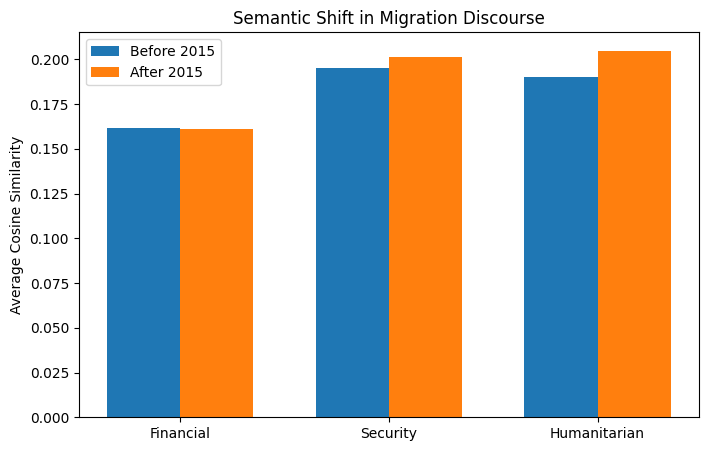

In [57]:
labels = ['Financial', 'Security', 'Humanitarian']

before_scores = [
    before_financial_mean,
    before_security_mean,
    before_humanitarian_mean
]

after_scores = [
    after_financial_mean,
    after_security_mean,
    after_humanitarian_mean
]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, before_scores, width, label='Before 2015')
plt.bar(x + width/2, after_scores, width, label='After 2015')

plt.xticks(x, labels)

plt.ylabel('Average Cosine Similarity')
plt.title('Semantic Shift in Migration Discourse')

plt.legend()

plt.show()

## Sentiment Analysis

This section examines the semantic representation of sentiment in migration-related discourse before and after 2015.

In [ ]:
#pip install git+"https://github.com/lauritswl/SemanticProjection"

In [ ]:
from semanticprojection.SemanticProjecter import SemanticProjector
# Define text as list:
list_of_texts = before_sentences
# Create an projector object from SemanticProjector class.
projector_before = SemanticProjector()
# Project the text, by using the Sentiment Vector:
projector_before.project_texts(
    texts=list_of_texts,
    concept_vector="Sentiment"
)
# Add a standardized column - adds interpretability in larger datasets
projector_before.standardize()

# Show results (stored in class atribute- self.results)
print(projector_before.results)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/1048 [00:00<?, ?it/s]

                                                    text  projection  \
0      Madam President, the National Alliance knows t...    0.482871   
1      (FR) Madam President, with regard to the Minut...    0.290550   
2      I would like to thank the Commissioner for his...    0.523505   
3      Mr President, ladies and gentlemen, Mr Foreign...    0.467832   
4      Mr President, Mr President of the Council, Mr ...    0.193405   
...                                                  ...         ...   
33513  in writing. - I voted against this proposal as...   -0.314112   
33514  in writing.  I voted against this EU-Georgia A...   -0.262626   
33515  in writing. - I voted against this proposal as...   -0.314112   
33516  in writing.  This Eastern Partnership agreemen...   -0.108249   
33517  written.  I support this proposal for an Assoc...    0.419643   

       standardized_projection  
0                     1.468465  
1                     0.714643  
2                     1.627732  
3  

In [ ]:
from semanticprojection.SemanticProjecter import SemanticProjector
# Define text as list:
list_of_texts = after_sentences
# Create an projector object from SemanticProjector class.
projector_after = SemanticProjector()
# Project the text, by using the Sentiment Vector:
projector_after.project_texts(
    texts=list_of_texts,
    concept_vector="Sentiment"
)
# Add a standardized column - adds interpretability in larger datasets
projector_after.standardize()

# Show results (stored in class atribute- self.results)
print(projector_after.results)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/1370 [00:00<?, ?it/s]

                                                    text  projection  \
0      on behalf of the EFDD Group. – Mr President, I...   -0.287848   
1      Mr President, ladies and gentlemen, let me fir...   -0.093774   
2      Madam President, please. I would like to start...   -0.193816   
3      Madam President, in the light of the events in...   -0.141277   
4      Madam President, in Venezuela there is politic...   -0.289199   
...                                                  ...         ...   
43807  Mr President, ladies and gentlemen, how far wi...    0.132104   
43808  Mr President, today, 8 February 2024, we have ...   -0.174822   
43809  Mr President, ladies and gentlemen, Commission...    0.300054   
43810  on behalf of the S&D Group. – Mr President, de...    0.244429   
43811  Mr President, Commissioner, ladies and gentlem...    0.334994   

       standardized_projection  
0                    -1.301924  
1                    -0.532461  
2                    -0.929107  
3  

In [ ]:
print("Before 2015:", projector_before.results["projection"].mean())

print("After 2015:",projector_after.results["projection"].mean())

Before 2015: 0.10822487154170032
After 2015: 0.04052377323664628


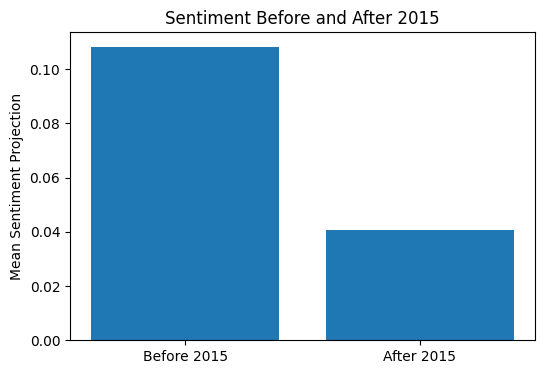

In [ ]:
before_mean = projector_before.results["projection"].mean()
after_mean = projector_after.results["projection"].mean()

periods = ["Before 2015", "After 2015"]
values = [before_mean, after_mean]

plt.figure(figsize=(6,4))
plt.bar(periods, values)

plt.ylabel("Mean Sentiment Projection")
plt.title("Sentiment Before and After 2015")

plt.show()

# Key Findings

- Migration-related terms were the most frequent of the three categories analysed, with **61,012 occurrences**, compared with **27,944 refugee-related** and **17,523 asylum-related** occurrences.

- The most frequent migration-related terms were **migration (23,257)**, **immigration (14,292)**, **migrants (11,264)**, and **immigrants (5,564)**.

- The most frequent refugee-related terms were **refugees (19,587)** and **refugee (8,337)**. The most frequent phrase was **“the refugee crisis” (1,959 occurrences)**.

- The most frequent asylum-related term was **asylum (17,385)**, while **“of asylum seekers” (1,087 occurrences)** was the most frequent asylum-related phrase.

- The yearly frequency analysis shows a **sharp increase in migration-related speeches in 2015 and 2016**. Migration-related speeches reached **4,808 in 2015** and **7,390 in 2016**, while refugee-related speeches reached **3,371 and 4,743**, respectively.

- Refugee-related discourse shows another noticeable increase in **2022**, reaching **881 speeches**, compared with **402 in 2021**. Migration-related speeches, however, decreased from **1,063 in 2021 to 822 in 2022**.

- Semantic analysis shows that the average **financial similarity remained unchanged at 0.161** before and after 2015, while **security similarity increased from 0.195 to 0.201** and **humanitarian similarity increased from 0.190 to 0.205**.

- Sentiment projection decreased from **0.108 before 2015 to 0.041 after 2015**, indicating a substantial decrease in the average sentiment projection of the analysed speeches.